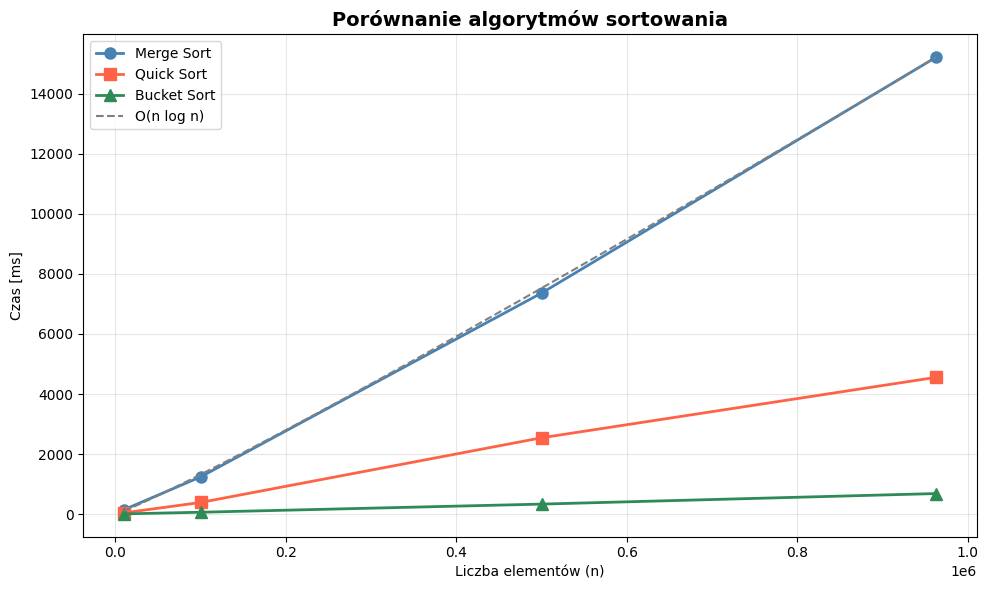

Zapisano wykres do data/porownanie_sortowania.png


In [13]:
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

def load_data(filename):
    data = defaultdict(list)
    with open(filename, 'r') as f:
        reader = csv.reader(f, delimiter=';')
        for row in reader:
            if not row:
                continue
            n = int(row[1])
            data[n].append(int(row[2]))
    return data

merge_data  = load_data('../data/merge_sort_time.csv')
quick_data  = load_data('../data/quick_sort_time.csv')
bucket_data = load_data('../data/bucket_sort_time.csv')

def avg_czas(data):
    ns = sorted(data.keys())
    return ns, [sum(data[n]) / len(data[n]) / 1e6 for n in ns]

merge_ns,  merge_times  = avg_czas(merge_data)
quick_ns,  quick_times  = avg_czas(quick_data)
bucket_ns, bucket_times = avg_czas(bucket_data)


ns_smooth = np.linspace(min(merge_ns), max(merge_ns), 500)
nlogn = ns_smooth * np.log2(ns_smooth)

scale = merge_times[-1] / (merge_ns[-1] * np.log2(merge_ns[-1]))
nlogn_scaled = nlogn * scale

plt.figure(figsize=(10, 6))
plt.plot(merge_ns,  merge_times,  marker='o', color='steelblue', linewidth=2, markersize=8, label='Merge Sort')
plt.plot(quick_ns,  quick_times,  marker='s', color='tomato',    linewidth=2, markersize=8, label='Quick Sort')
plt.plot(bucket_ns, bucket_times, marker='^', color='seagreen',  linewidth=2, markersize=8, label='Bucket Sort')
plt.plot(ns_smooth, nlogn_scaled, color='gray', linewidth=1.5, linestyle='--', label='O(n log n)')

plt.title('Porównanie algorytmów sortowania', fontsize=14, fontweight='bold')
plt.xlabel('Liczba elementów (n)')
plt.ylabel('Czas [ms]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/fig/porownanie_sortowania.png', dpi=150, bbox_inches='tight')
plt.show()

print("Zapisano wykres do data/porownanie_sortowania.png")